In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.features.feature_engineer.rpm_features import *

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s21 = pd.read_csv('data/raw/season_stats/S21.csv').sort_values(by='GAME_DATE')
p21 = pd.read_csv('data/raw/playoff_stats/P21.csv').sort_values(by='GAME_DATE')
s21 = pd.concat([s21, p21])

s22 = pd.read_csv('data/raw/season_stats/S22.csv').sort_values(by='GAME_DATE')
p22 = pd.read_csv('data/raw/playoff_stats/P22.csv').sort_values(by='GAME_DATE')
s22 = pd.concat([s22, p22])

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
p23 = pd.read_csv('data/raw/playoff_stats/P23.csv').sort_values(by='GAME_DATE')
s23 = pd.concat([s23, p23])

s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
p24 = pd.read_csv('data/raw/playoff_stats/P24.csv').sort_values(by='GAME_DATE')
s24 = pd.concat([s24, p24])

s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
p25 = pd.read_csv('data/raw/playoff_stats/P25.csv').sort_values(by='GAME_DATE')
s25 = pd.concat([s25, p25])

s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
p26 = pd.read_csv('data/raw/playoff_stats/P26.csv').sort_values(by='GAME_DATE')
s26 = pd.concat([s26, p26])
s26

,Unnamed: 0.1,Unnamed: 0,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE,TEAM_SPREAD,GAME_TOTAL,STARTING,PTS_PER_MIN,AST_PER_MIN,REB_PER_MIN,IS_HOME,POSITION_ENCODED,name
0,0.0,0.0,2025-26,1630611,Gui Santos,Gui,1610612744,GSW,Golden State Warriors,22500002,2025-10-21,GSW @ LAL,W,2.646667,0,0,0.000,0,0,0.000,0,0,0.000,0,0,0,0,1,0,0,0,0,0,0,0,-1.0,0,0,0.0,1,2:39,1,94.9,100.0,100.0,123.0,120.0,120.0,-28.0,-20.0,-20.0,0.000,0.00,0.0,0.000,0.000,0.000,100.0,100.0,0.000,0.000,0.167,0.158,101.56,99.75,83.12,99.75,-0.111,6,0.0,0.0,NaN,4.50,0.21,1,0,1,4,0,0,3,0,0,0.000,0,0,0.000,1,1,1.00,38,78,0.487,17,40,0.425,26,29,0.897,9,31,40,29,19.0,10,4,2,27,21,119,10.0,118.1,119.0,106.5,106.9,11.6,12.1,0.763,1.53,21.0,0.209,0.744,0.477,0.190,0.596,0.656,101.5,101.00,84.17,100,0.546,1610612747,LAL,Los Angeles Lakers,42,77,0.545,8,32,0.250,17,28,0.607,7,32,39,23,20.0,7,2,4,21,27,109,-10.0,106.5,106.9,118.1,119.0,-11.6,-12.1,0.548,1.15,16.9,0.256,0.791,0.523,0.196,0.597,0.610,101.5,101.00,84.17,102,0.454,0,PF,23.0,1.0,227.5,0,0.000000,0.000000,0.000000,0,1,NaN
22,19.0,20.0,2025-26,1628983,Shai Gilgeous-Alexander,Shai,1610612760,OKC,Oklahoma City Thunder,22500001,2025-10-21,OKC vs. HOU,W,47.216667,12,26,0.462,1,9,0.111,10,14,0.714,0,5,5,5,3,2,2,2,2,10,35,3,57.5,0,0,54.0,1,47:13,1,105.6,111.1,111.1,100.6,104.3,104.3,5.0,6.8,6.8,0.208,1.67,12.2,0.000,0.109,0.051,7.3,7.5,0.481,0.544,0.340,0.336,97.15,93.02,77.52,93.02,0.182,90,12.0,26.0,G,3.75,2.89,4,6,9,104,0,0,63,2,4,0.500,10,22,0.455,3,5,0.60,46,104,0.442,13,52,0.250,20,25,0.800,11,27,38,29,12.0,12,4,5,27,26,125,1.0,107.8,112.6,103.6,107.8,4.1,4.8,0.630,2.42,18.5,0.283,0.518,0.397,0.108,0.505,0.543,97.5,93.52,77.93,111,0.521,1610612745,HOU,Houston Rockets,43,97,0.443,11,39,0.282,27,31,0.871,16,36,52,23,25.0,6,5,4,26,27,124,-1.0,103.6,107.8,107.8,112.6,-4.1,-4.8,0.535,0.92,13.9,0.482,0.717,0.603,0.217,0.500,0.560,97.5,93.52,77.93,115,0.479,0,PG,27.0,-6.5,226.0,1,0.741264,0.105895,0.105895,1,2,NaN
23,1.0,22.0,2025-26,1630559,Austin Reaves,Austin,1610612747,LAL,Los Angeles Lakers,22500002,2025-10-21,LAL vs. GSW,L,36.333333,9,16,0.563,1,5,0.200,7,10,0.700,1,4,5,9,5,2,0,1,5,10,26,-14,46.5,0,0,45.0,1,36:20,1,99.5,102.7,102.7,121.9,119.7,119.7,-22.3,-17.1,-17.1,0.409,1.80,26.5,0.031,0.148,0.085,14.7,14.5,0.594,0.637,0.301,0.308,100.43,99.74,83.12,99.74,0.147,75,9.0,16.0,

In [3]:
# ── Feature engineering loop ─────────────────────────────────────────────────
# CHANGED: added SEASON label so S26 can be isolated as a blind holdout.

res = []
season_map = {0: 'S21', 1: 'S22', 2: 'S23', 3: 'S24', 4: 'S25', 5: 'S26'}

for i, season_df in enumerate([s21, s22, s23, s24, s25, s26]):
    season_df["GAME_DATE"] = pd.to_datetime(season_df["GAME_DATE"])
    season_df = season_df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)
    season_df['STARTING'] = season_df['START_POSITION'].notna().astype(int)

    # Derived per-minute rates (before rolling features)
    season_df['MIN']          = season_df['MIN'].round(2)
    season_df["REB_PER_MIN"]  = season_df["REB"]  / season_df["MIN"].replace(0, np.nan)
    season_df["OREB_PER_MIN"] = season_df["OREB"] / season_df["MIN"].replace(0, np.nan)
    season_df["DREB_PER_MIN"] = season_df["DREB"] / season_df["MIN"].replace(0, np.nan)
    season_df['ORBC_PER_MIN'] = season_df['ORBC'] / season_df['MIN'].replace(0, np.nan)
    season_df['DRBC_PER_MIN'] = season_df['DRBC'] / season_df['MIN'].replace(0, np.nan)
    season_df['RBC_PER_MIN']  = season_df['RBC']  / season_df['MIN'].replace(0, np.nan)
    season_df['DIST_PER_MIN'] = season_df['DIST'] / season_df['MIN'].replace(0, np.nan)

    season_df = rpm_features(season_df)

    season_df['TEAM_REB_PER_MIN_RANK_L10'] = season_df.groupby(['TEAM_ID', 'GAME_DATE'])['REB_PER_MIN_roll10'].rank(ascending=False, method='dense')
    season_df['MEDIAN_REB_PER_MIN_L10']    = season_df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(
        lambda x: x.shift(1).rolling(10).median().round(2))
    season_df['REB_PER_MIN_TREND'] = season_df['REB_PER_MIN_5_ewm'] - season_df['REB_PER_MIN_10_ewm']
    season_df['RPM_SEASON_STD']    = season_df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(
        lambda x: x.expanding().std().shift(1))
    season_df['REB_ROLL10_SLOPE'] = (
        season_df.groupby('PLAYER_ID')['REB_PER_MIN_roll10']
        .transform(lambda x: x.shift(1).rolling(5).apply(
            lambda y: np.polyfit(np.arange(len(y)), y, 1)[0], raw=True)))
    season_df['REB_ROLL10_SLOPE_NORM'] = (
    season_df['REB_ROLL10_SLOPE'] / season_df['REB_PER_MIN_season_avg'].replace(0, np.nan))
    season_df["GP"] = season_df.groupby("PLAYER_ID").cumcount()

    season_df['POSITION_ENC'] = LabelEncoder().fit_transform(season_df['POS'])
        # Percentiles need moderate sample size
    player_rpm_grp = season_df.groupby('PLAYER_ID')['REB_PER_MIN']
    season_df['REB_PER_MIN_P10_L10'] = player_rpm_grp.transform(
        lambda x: x.shift(1).rolling(10, min_periods=5).quantile(0.1)
    )
    season_df['REB_PER_MIN_P50_L10'] = player_rpm_grp.transform(
        lambda x: x.shift(1).rolling(10, min_periods=5).quantile(0.5)
    )
    season_df['REB_PER_MIN_P90_L10'] = player_rpm_grp.transform(
        lambda x: x.shift(1).rolling(10, min_periods=5).quantile(0.9)
    )
    season_df['OREB_DREB_RATIO'] = season_df['OREB_PCT_10_ewm'] / season_df['DREB_PCT_10_ewm'].replace(0, np.nan)
    season_df['OPP_MISS_RATE'] = 1 - season_df['OPP_EFG_PCT_roll10']
    season_df['SEASON'] = season_map[i]   # ← NEW: season tag

    season_df = season_df[(season_df['MIN'] >= 10) | (season_df['STARTING'] == 1)]
    res.append(season_df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
print(df.shape)
print(df['SEASON'].value_counts().sort_index())

(145837, 344)
SEASON
S21    21105
S22    25198
S23    24890
S24    24698
S25    25032
S26    24914
Name: count, dtype: int64


In [ ]:
# RPM_FEATURES = [
#     # ── Tier 1: Core signal (consensus > 0.20) ────────────────────────────────
#     'REB_PER_MIN_season_avg',       # dominant — 3.5x stronger than anything else
#     'REB_PER_MIN_10_ewm',           # strong #2, keep
#     'RBC_PER_MIN_10_ewm',           # strong #2, keep
#     'POSITION_ENC',                 # strong #3, keep
#     'REB_PER_MIN_roll5',            # strong #4, keep

#     # ── Tier 2: Solid contributors (keep=True, consensus > 0.01) ─────────────
#     'DREB_PCT_season_avg',          # significant, positive ablation
#     'OPP_TEAM_DREB_ALLOWED',        # opponent defensive glass weakness
#     'REB_ROLL10_SLOPE',             # momentum signal, positive ablation
#     'EXPECTED_PACE',                # possessions available
#     'OPP_TEAM_OREB_ALLOWED',        # opponent offensive glass weakness
#     'MIN_season_avg',               # baseline opportunity
#     'RPM_SEASON_STD',               # player consistency signal
#     'OREB_PCT_season_avg',          # significant, positive ablation
#     'DREB_PER_MIN_season_avg',      # significant, positive ablation
#     'OPP_FGA_roll10',               # positive ablation overrules weak perm signal    

#     'REB_PER_MIN_P10_L10',
#     'REB_PER_MIN_P50_L10',
#     'REB_PER_MIN_P90_L10',
# ]
RPM_FEATURES = [
    'REB_PER_MIN_season_avg',
    'REB_PER_MIN_10_ewm',
    'OREB_DREB_RATIO',
    'POSITION_ENC',
    'RBC_PER_MIN_10_ewm',
    'RPM_SEASON_STD',
    'REB_ROLL10_SLOPE',
    'REB_PER_MIN_P10_L10',
    'REB_PER_MIN_P90_L10',
    
]

In [28]:
# ── Train/holdout split ───────────────────────────────────────────────────────
# CHANGED: S26 is held out entirely. The model never sees it during training
# or hyperparameter evaluation. Evaluate on it ONCE at the very end.

HOLDOUT_SEASON = 'S26'

df_model   = df[df['SEASON'] != HOLDOUT_SEASON].copy()   # S21–S25
df_holdout = df[df['SEASON'] == HOLDOUT_SEASON].copy()   # S26 blind test

# STARTING is kept for starter/bench stratification in score_fold (not necessarily in RPM_FEATURES).
# PLAYER_NAME is kept separately for diagnostics only.
KEEP_COLS = RPM_FEATURES + ["REB_PER_MIN", "MIN", "GAME_DATE", "PLAYER_NAME", "STARTING"]

rpm_df = (
    df_model[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

rpm_holdout = (
    df_holdout[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = rpm_df[RPM_FEATURES]
y = rpm_df["REB_PER_MIN"]

print(f"Train pool (S21–S25) : {len(rpm_df):,} rows")
print(f"Holdout   (S26)      : {len(rpm_holdout):,} rows")
print(f"Date range (train)   : {rpm_df['GAME_DATE'].min().date()} → {rpm_df['GAME_DATE'].max().date()}")
print(f"Date range (holdout) : {rpm_holdout['GAME_DATE'].min().date()} → {rpm_holdout['GAME_DATE'].max().date()}")

Train pool (S21–S25) : 120,923 rows
Holdout   (S26)      : 24,914 rows
Date range (train)   : 2020-12-22 → 2025-06-22
Date range (holdout) : 2025-10-21 → 2026-05-13


In [29]:
from sklearn.model_selection import TimeSeriesSplit

quantiles = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective             = "reg:quantileerror",
    n_estimators          = 1344,
    max_depth             = 3,
    learning_rate         = 0.0199208375412252,
    subsample             = 0.6525095024077675,
    colsample_bytree      = 0.7424913081435832,
    reg_alpha             = 3.890568820995351,
    reg_lambda            = 4.755281357016035,
    min_child_weight      = 10,
    n_jobs                = -1,
    random_state          = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key         = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds

In [30]:
# ── Helpers ───────────────────────────────────────────────────────────────────

RPM_TIERS = {
    "<0.15 reb/min":    lambda a: a < 0.15,
    "0.15-0.25 reb/min": lambda a: (a >= 0.15) & (a < 0.25),
    "0.25-0.40 reb/min": lambda a: (a >= 0.25) & (a < 0.40),
    "0.40+ reb/min":    lambda a: a >= 0.40,
}


def score_fold(actual, preds, models, fold_label, starting=None):
    """
    Score a single fold.
    CHANGED: now accepts `starting` (bool/int array) and reports
    stratified MAE + coverage across roles and RPM tiers.
    Pass `starting` from `rpm_df` / `rpm_holdout` aligned to the validation rows
    (`STARTING` may not be included in RPM_FEATURES).
    """
    lower  = preds["q_0.10"]
    median = preds["q_0.50"]
    upper  = preds["q_0.90"]

    mae      = mean_absolute_error(actual, median)
    r2       = r2_score(actual, median)
    coverage = np.mean((actual >= lower) & (actual <= upper))

    metrics = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mae,
        "r2":             r2,
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }

    print(f"\n{fold_label}")
    print(f"  Overall  | n={len(actual):5d} | MAE: {mae:.4f} | R²: {r2:.3f} | 80% Coverage: {coverage:.1%}")

    # ── Role stratification (starter vs bench) ────────────────────────────────
    if starting is not None:
        for role, mask in [("Starters", starting == 1), ("Bench", starting == 0)]:
            if mask.sum() == 0:
                continue
            r_mae = mean_absolute_error(actual[mask], median[mask])
            r_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
            metrics[f"mae_{role}"]      = r_mae
            metrics[f"coverage_{role}"] = r_cov
            print(f"  {role:10s} | n={mask.sum():5d} | MAE: {r_mae:.4f} | Coverage: {r_cov:.1%}")

    # ── RPM-tier stratification ────────────────────────────────────────────────
    for tier, fn in RPM_TIERS.items():
        mask = fn(actual)
        if mask.sum() == 0:
            continue
        t_mae = mean_absolute_error(actual[mask], median[mask])
        t_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
        metrics[f"mae_{tier}"]      = t_mae
        metrics[f"coverage_{tier}"] = t_cov
        print(f"  {tier:20s} | n={mask.sum():5d} | MAE: {t_mae:.4f} | Coverage: {t_cov:.1%}")

    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparam comparison only)
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────────")
tscv         = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    starting_val = rpm_df.iloc[val_idx]["STARTING"].values

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models,
                         f"TSCV fold {fold+1}", starting=starting_val)
    tscv_results.append(metrics)

maes = [r["mae"]            for r in tscv_results]
r2s  = [r["r2"]             for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (date-based, production simulation)
#
# CHANGED: splits are now on unique GAME_DATEs, not row indices.
# This ensures no single game date is split across train/val,
# which was the root cause of intra-game leakage in the original code.
# ════════════════════════════════════════════════════════════════════════════

print("\n── Phase 2: Walk-Forward Validation (date-based) ───────────────────")

assert rpm_df["GAME_DATE"].is_monotonic_increasing, "rpm_df must be sorted by GAME_DATE"

unique_dates = rpm_df["GAME_DATE"].unique()          # sorted unique game dates
n_dates      = len(unique_dates)

TRAIN_WINDOW = round(n_dates * 0.50)                 # dates in each training window
STEP_SIZE    = round(n_dates * 0.10)                 # dates to advance each fold
N_FOLDS      = 4

print(f"Unique game dates in pool : {n_dates}")
print(f"Training window           : {TRAIN_WINDOW} dates (~{TRAIN_WINDOW/n_dates:.0%})")
print(f"Step size                 : {STEP_SIZE} dates (~{STEP_SIZE/n_dates:.0%})")

wf_results  = []
models_last = None   # will hold the final fold's models for downstream cells

for fold in range(N_FOLDS):
    d_train_start = fold * STEP_SIZE
    d_train_end   = d_train_start + TRAIN_WINDOW
    d_val_end     = d_train_end   + STEP_SIZE

    if d_val_end > n_dates:
        print(f"\nFold {fold+1}: not enough dates remaining — stopping at {fold} folds.")
        break

    train_dates = unique_dates[d_train_start:d_train_end]
    val_dates   = unique_dates[d_train_end:d_val_end]

    # CHANGED: mask on dates so every player in a given game date
    # lands on the same side of the split — no intra-game leakage.
    train_mask = rpm_df["GAME_DATE"].isin(train_dates)
    val_mask   = rpm_df["GAME_DATE"].isin(val_dates)

    X_tr,  X_val  = X[train_mask], X[val_mask]
    y_tr,  y_val  = y[train_mask], y[val_mask]
    starting_val  = rpm_df.loc[val_mask, "STARTING"].values

    label = (f"WF fold {fold+1}  "
             f"({train_dates[-1].date()} → {val_dates[-1].date()})")

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, label, starting=starting_val)
    metrics.update({
        "train_start": train_dates[0],
        "train_end":   train_dates[-1],
        "val_end":     val_dates[-1],
        # stash masks so downstream cells can reconstruct without retraining
        "train_mask":  train_mask,
        "val_mask":    val_mask,
    })
    wf_results.append(metrics)

    # keep last fold for residual plots + SHAP
    models_last   = models
    preds_last    = preds
    X_val_last    = X_val
    y_val_last    = y_val
    starting_last = starting_val

# ── Walk-forward summary ──────────────────────────────────────────────────────
maes = [r["mae"]            for r in wf_results]
r2s  = [r["r2"]             for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]

print(f"\n{'─'*60}")
print(f"Walk-Forward Summary ({len(wf_results)}/{N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# CHANGED: per-fold coverage table — catches folds where interval collapses
# or over-covers without hiding it in the mean.
print(f"\n{'─'*60}")
print("Per-fold coverage breakdown (target 80%):")
print(f"  {'Fold':<45} {'Coverage':>10}  {'Starters':>10}  {'Bench':>10}")
for r in wf_results:
    s_cov = r.get("coverage_Starters", float('nan'))
    b_cov = r.get("coverage_Bench",    float('nan'))
    print(f"  {r['fold']:<45} {r['coverage_80pct']:>9.1%}  {s_cov:>9.1%}  {b_cov:>9.1%}")

# CHANGED: stratified MAE summary across all folds
print(f"\nPer-fold MAE by RPM tier:")
tier_keys = list(RPM_TIERS.keys())
header = f"  {'Fold':<45} " + "  ".join(f"{t:>20}" for t in tier_keys)
print(header)
for r in wf_results:
    row = f"  {r['fold']:<45} "
    row += "  ".join(f"{r.get(f'mae_{t}', float('nan')):>20.4f}" for t in tier_keys)
    print(row)

# Drift check
max_mae = max(maes)
print(f"\nMAE over folds (stable = good, rising = model aging):")
for r in wf_results:
    bar = "█" * int((r["mae"] / max_mae) * 20)
    print(f"  {r['fold']:<45} {r['mae']:.4f}  {bar}")

last_fold = wf_results[-1]

── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n=20153 | MAE: 0.0726 | R²: 0.401 | 80% Coverage: 80.1%
  Starters   | n=11172 | MAE: 0.0663 | Coverage: 83.1%
  Bench      | n= 8981 | MAE: 0.0805 | Coverage: 76.2%
  <0.15 reb/min        | n= 9066 | MAE: 0.0596 | Coverage: 78.9%
  0.15-0.25 reb/min    | n= 5940 | MAE: 0.0550 | Coverage: 91.9%
  0.25-0.40 reb/min    | n= 3816 | MAE: 0.0906 | Coverage: 76.4%
  0.40+ reb/min        | n= 1331 | MAE: 0.1890 | Coverage: 45.3%

TSCV fold 2
  Overall  | n=20153 | MAE: 0.0710 | R²: 0.398 | 80% Coverage: 80.1%
  Starters   | n=11304 | MAE: 0.0650 | Coverage: 82.5%
  Bench      | n= 8849 | MAE: 0.0787 | Coverage: 77.1%
  <0.15 reb/min        | n= 9441 | MAE: 0.0598 | Coverage: 78.0%
  0.15-0.25 reb/min    | n= 5917 | MAE: 0.0554 | Coverage: 92.3%
  0.25-0.40 reb/min    | n= 3655 | MAE: 0.0887 | Coverage: 76.0%
  0.40+ reb/min        | n= 1140 | MAE: 0.1885 | Coverage: 47.7%

TSCV fold 3
  Overall  | 

In [39]:
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

tscv = TimeSeriesSplit(n_splits=3)  # fewer splits = faster tuning

def objective(trial):
    params = {
        "objective": "reg:quantileerror",
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "n_jobs": -1,
        "random_state": 42,
        "early_stopping_rounds": 50,
    }
    maes = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = XGBRegressor(**params, quantile_alpha=0.5)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = m.predict(X_val)
        maes.append(mean_absolute_error(y_val, pred))
    return float(np.mean(maes))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best MAE (mean over TSCV, median model):", study.best_value)
print("Best params:", study.best_params)

[I 2026-05-14 19:04:07,366] A new study created in memory with name: no-name-8a3b6474-884a-4712-b3a3-b34bd865d2ba
Best trial: 0. Best value: 0.0719836:   2%|▏         | 1/50 [00:04<03:25,  4.19s/it]

[I 2026-05-14 19:04:11,552] Trial 0 finished with value: 0.0719836084247979 and parameters: {'n_estimators': 1062, 'max_depth': 12, 'learning_rate': 0.08960785365368121, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.003775887545682684, 'reg_lambda': 0.0016400214911202306, 'min_child_weight': 9}. Best is trial 0 with value: 0.0719836084247979.


Best trial: 1. Best value: 0.0716551:   4%|▍         | 2/50 [00:20<08:52, 11.09s/it]

[I 2026-05-14 19:04:27,481] Trial 1 finished with value: 0.07165514329206464 and parameters: {'n_estimators': 1402, 'max_depth': 10, 'learning_rate': 0.010636066512540286, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'reg_alpha': 0.00610149136730271, 'reg_lambda': 0.004705059281907645, 'min_child_weight': 2}. Best is trial 1 with value: 0.07165514329206464.


Best trial: 2. Best value: 0.0713607:   6%|▌         | 3/50 [00:25<06:28,  8.26s/it]

...

[I 2026-05-14 19:12:28,595] Trial 47 finished with value: 0.0710595047196546 and parameters: {'n_estimators': 1273, 'max_depth': 4, 'learning_rate': 0.028338357022218114, 'subsample': 0.9655789338036683, 'colsample_bytree': 0.5533091726941143, 'reg_alpha': 0.7186152448171444, 'reg_lambda': 1.4193343699113654, 'min_child_weight': 5}. Best is trial 32 with value: 0.07103794219238545.


Best trial: 32. Best value: 0.0710379:  98%|█████████▊| 49/50 [08:31<00:10, 10.92s/it]

[I 2026-05-14 19:12:38,848] Trial 48 finished with value: 0.07107826707187097 and parameters: {'n_estimators': 1116, 'max_depth': 5, 'learning_rate': 0.013439417475431802, 'subsample': 0.5820893376808152, 'colsample_bytree': 0.6511860830972044, 'reg_alpha': 0.16595742691624346, 'reg_lambda': 0.5236564663146265, 'min_child_weight': 7}. Best is trial 32 with value: 0.07103794219238545.


Best trial: 32. Best value: 0.0710379: 100%|██████████| 50/50 [08:38<00:00, 10.37s/it]

[I 2026-05-14 19:12:45,723] Trial 49 finished with value: 0.07134435408920722 and parameters: {'n_estimators': 1342, 'max_depth': 9, 'learning_rate': 0.02214784853199596, 'subsample': 0.7314293166807165, 'colsample_bytree': 0.5267653851789145, 'reg_alpha': 0.005360985127958661, 'reg_lambda': 3.0549586261411195, 'min_child_weight': 6}. Best is trial 32 with value: 0.07103794219238545.
Best MAE (mean over TSCV, median model): 0.07103794219238545
Best params: {'n_estimators': 1317, 'max_depth': 4, 'learning_rate': 0.013204853952843792, 'subsample': 0.6679300954582128, 'colsample_bytree': 0.5948540485867515, 'reg_alpha': 2.7408844938198635, 'reg_lambda': 0.6458095165703245, 'min_child_weight': 5}


### Residual Visuals

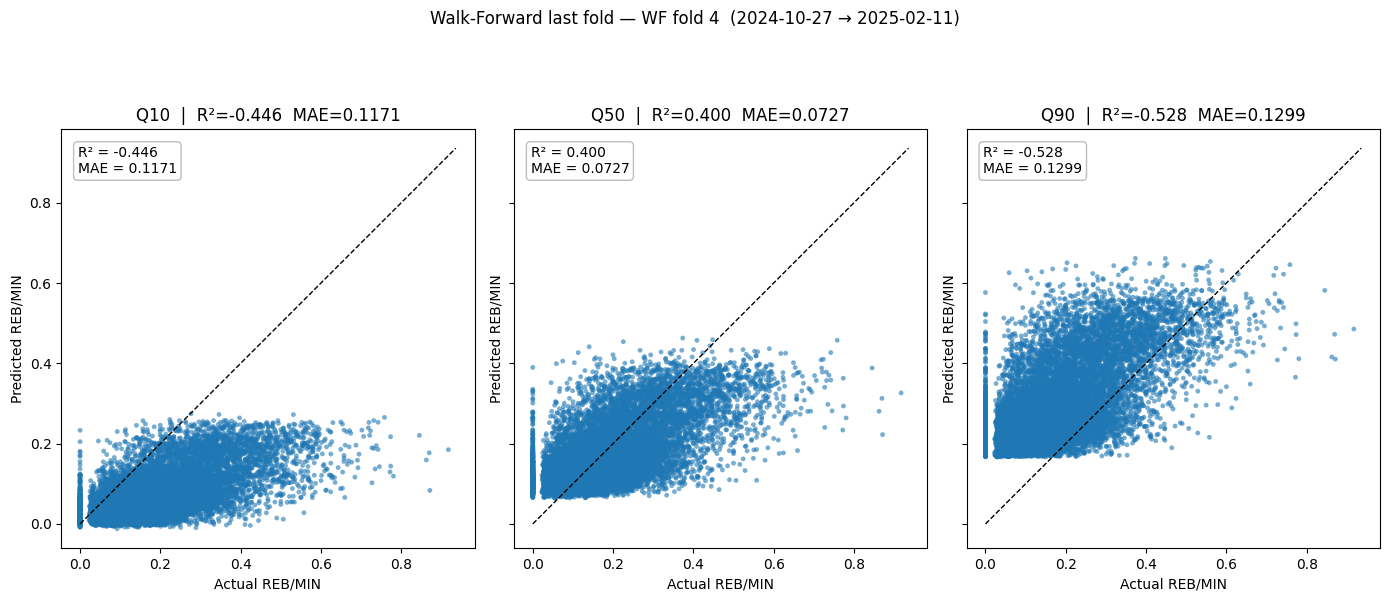

Per-quantile fit on last validation fold:
  Q10: R²=-0.446  MAE=0.1171
  Q50: R²=+0.400  MAE=0.0727
  Q90: R²=-0.528  MAE=0.1299

Coverage per quantile (should match quantile value):
  Q10: 10.3%  (target 10%, delta +0.3%)  ✓
  Q50: 49.5%  (target 50%, delta -0.5%)  ✓
  Q90: 89.5%  (target 90%, delta -0.5%)  ✓

80% interval width (Q10→Q90):
  mean   : 0.2277 reb/min
  median : 0.2140 reb/min
  std    : 0.0555 reb/min


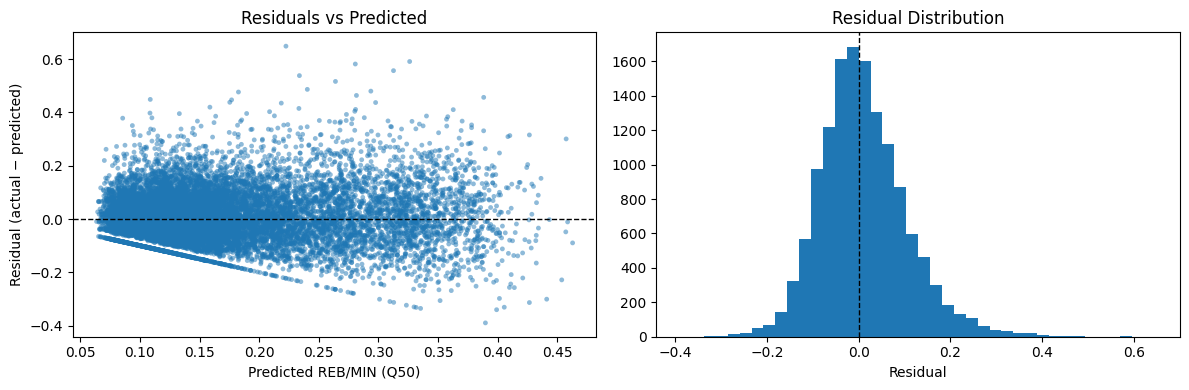


Residual summary:
  mean bias : +0.0101  (close to 0 = unbiased)
  std       : 0.0955

Residuals by role:
  Starters   | n= 7530 | bias=+0.0088 | std=0.0865
  Bench      | n= 6055 | bias=+0.0117 | std=0.1056

Residuals by RPM tier:
  <0.15 reb/min        | n= 6190 | bias=-0.0501 | std=0.0571
  0.15-0.25 reb/min    | n= 3993 | bias=+0.0206 | std=0.0656
  0.25-0.40 reb/min    | n= 2537 | bias=+0.0788 | std=0.0774
  0.40+ reb/min        | n=  865 | bias=+0.1907 | std=0.0979


In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull directly from stored walk-forward variables ─────────────────────────
# models_last, preds_last, X_val_last, y_val_last, starting_last
# are all set at the end of the walk-forward loop — no reconstruction needed.

y_true    = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.4f}")
    ax.set_xlabel("Actual REB/MIN")
    ax.set_ylabel("Predicted REB/MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.4f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.4f}")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    flag     = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

# ── interval width ────────────────────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.4f} reb/min")
print(f"  median : {np.median(interval_width):.4f} reb/min")
print(f"  std    : {interval_width.std():.4f} reb/min")

# ── residual plot ─────────────────────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted REB/MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.4f}  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.4f}")

# ── residuals stratified by role and RPM tier ─────────────────────────────────
starting_last = rpm_df.loc[X_val_last.index, "STARTING"].values

print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.4f} | std={r.std():.4f}")

print("\nResiduals by RPM tier:")
for tier, fn in RPM_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:20s} | n={mask.sum():5d} | bias={r.mean():+.4f} | std={r.std():.4f}")


── q_0.10 ──


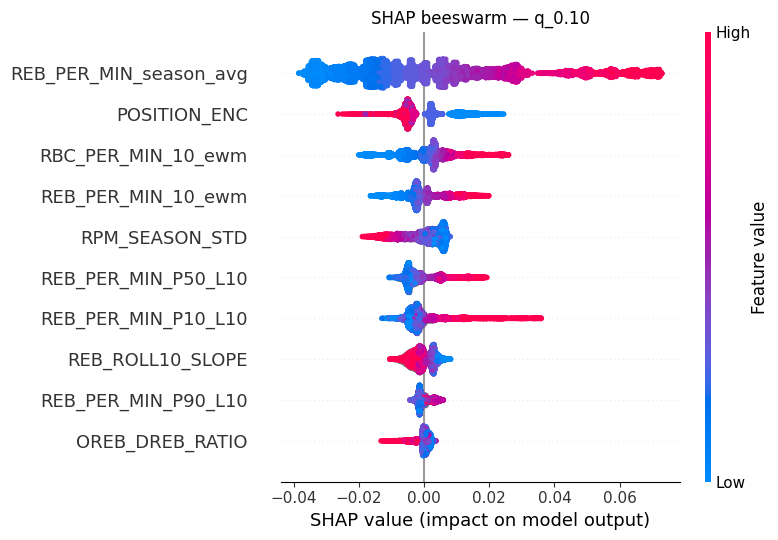


── q_0.50 ──


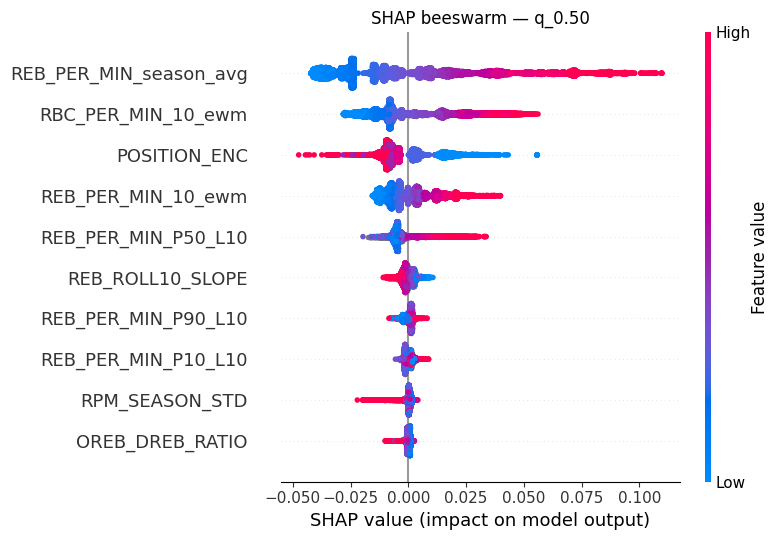


── q_0.90 ──


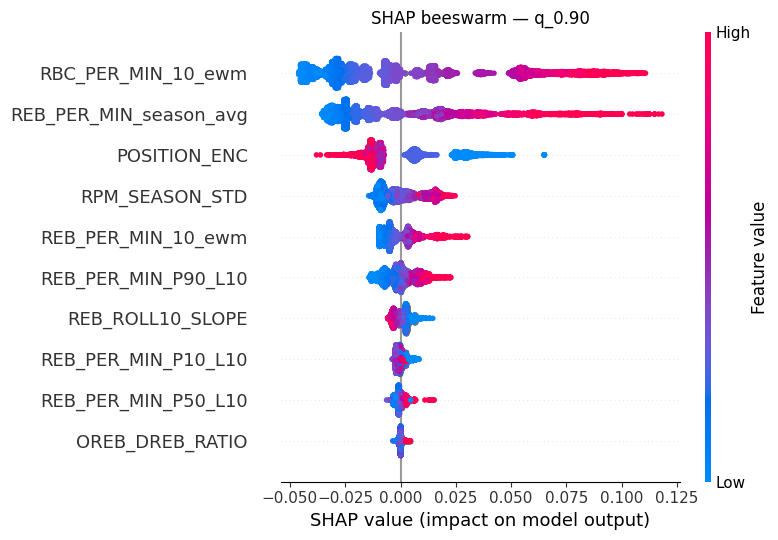

In [33]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()

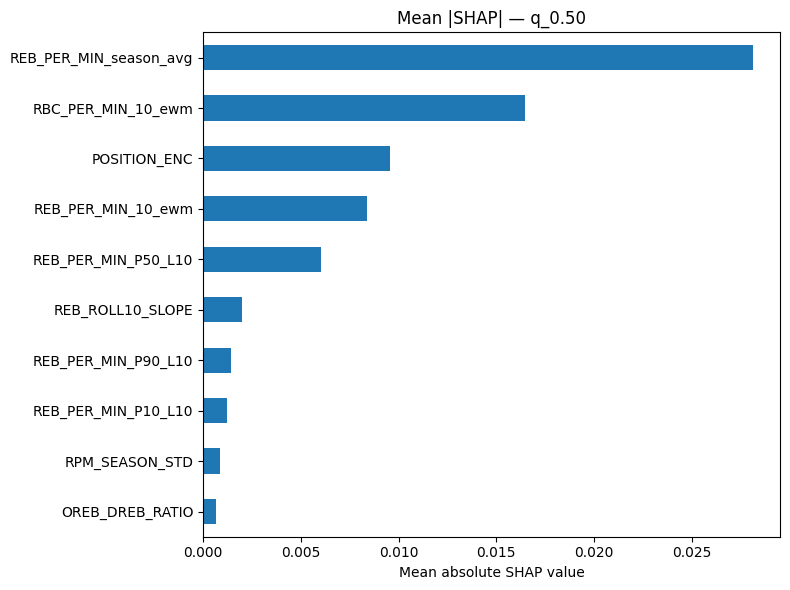

In [34]:
model = models_last["q_0.50"]

explainer   = shap.TreeExplainer(model, model_output="raw")
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=RPM_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

In [35]:
# ── Permutation importance — on VALIDATION set ───────────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

def pinball_50(y_true, y_pred, alpha=0.50):
    residual = y_true - y_pred
    return -np.mean(np.where(residual >= 0, alpha * residual, (alpha - 1) * residual))

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature":    X_val_last.columns,
        "importance": result.importances_mean,
        "std":        result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(6)
pi_df["std"]        = pi_df["std"].round(6)

pi_df["p_value"] = sp_stats.ttest_1samp(
    result.importances, 0.0, axis=1
).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                   feature  importance       std  p_value  significant
1   REB_PER_MIN_season_avg    0.004042  0.000091   0.0000         True
2       RBC_PER_MIN_10_ewm    0.001384  0.000058   0.0000         True
3             POSITION_ENC    0.000961  0.000050   0.0000         True
4       REB_PER_MIN_10_ewm    0.000408  0.000034   0.0000         True
5      REB_PER_MIN_P50_L10    0.000373  0.000031   0.0000         True
6         REB_ROLL10_SLOPE    0.000061  0.000017   0.0000         True
7      REB_PER_MIN_P10_L10    0.000038  0.000008   0.0000         True
8           RPM_SEASON_STD    0.000020  0.000007   0.0000         True
9          OREB_DREB_RATIO    0.000014  0.000006   0.0000         True
10     REB_PER_MIN_P90_L10    0.000002  0.000009   0.1762        False


In [36]:
from sklearn.metrics import mean_squared_error

# ── pull train/val slices from last fold's stored masks ───────────────────────
train_mask_last = last_fold["train_mask"]
val_mask_last   = last_fold["val_mask"]

X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]


def rmse_median_ablation(feature_cols):
    m = XGBRegressor(**XGB_PARAMS, quantile_alpha=0.50)
    m.fit(
        X_tr_last[feature_cols], y_tr_last,
        eval_set=[(X_va_last[feature_cols], y_va_last)],
        verbose=False,
    )
    pred = m.predict(X_va_last[feature_cols])
    return float(np.sqrt(mean_squared_error(y_va_last, pred)))


baseline_rmse = rmse_median_ablation(RPM_FEATURES)
print(f"Baseline RMSE (all features): {baseline_rmse:.6f}")

rows = []
for feat in RPM_FEATURES:
    cols         = [c for c in RPM_FEATURES if c != feat]
    ablated_rmse = rmse_median_ablation(cols)
    delta        = ablated_rmse - baseline_rmse  # positive = removing it hurt = feature helped
    rows.append({"feature": feat, "ablated_rmse": round(ablated_rmse, 6), "delta_rmse": round(delta, 6)})

ablation_df = (
    pd.DataFrame(rows)
    .sort_values("delta_rmse", ascending=False)
    .reset_index(drop=True)
)
ablation_df.index += 1
print(ablation_df.to_string())

Baseline RMSE (all features): 0.096018
                   feature  ablated_rmse  delta_rmse
1             POSITION_ENC      0.096554    0.000536
2       RBC_PER_MIN_10_ewm      0.096363    0.000345
3   REB_PER_MIN_season_avg      0.096260    0.000242
4         REB_ROLL10_SLOPE      0.096102    0.000084
5      REB_PER_MIN_P50_L10      0.096055    0.000038
6      REB_PER_MIN_P10_L10      0.096056    0.000038
7      REB_PER_MIN_P90_L10      0.096023    0.000005
8           RPM_SEASON_STD      0.095979   -0.000039
9          OREB_DREB_RATIO      0.095975   -0.000043
10      REB_PER_MIN_10_ewm      0.095898   -0.000120


In [37]:
from scipy import stats

# ── all three methods use the val set for consistency ─────────────────────────
model = models_last["q_0.50"]

_shap_expl     = shap.TreeExplainer(model, model_output="raw")
_shap_vals     = _shap_expl(X_val_last)                        # ← val set, not X_tr
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature":       X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(
    shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int)
)

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature":    X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(
        result.importances, 0.0, axis=1, nan_policy="omit"
    ).pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": RPM_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv,    on="feature", how="left")
    .merge(abla,       on="feature", how="left")
)

_ms       = feature_audit["mean_abs_shap"].astype(float)
_mp       = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()

feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2

feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1

# flag features that are significant in perm AND positive in ablation
feature_audit["keep"] = (
    (feature_audit["perm_pvalue"] < 0.05) &
    (feature_audit["ablation_delta"] > 0)
)

print(feature_audit.to_string())

                   feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1   REB_PER_MIN_season_avg       0.028119          1          1         0.004042             0.000091  2.108404e-49        0.000242   1.000000   1.000000   1.000000   True
2       RBC_PER_MIN_10_ewm       0.016470          2          2         0.001384             0.000058  1.347361e-41        0.000345   0.585727   0.342405   0.464066   True
3             POSITION_ENC       0.009552          3          3         0.000961             0.000050  7.376984e-39        0.000536   0.339705   0.237754   0.288729   True
4       REB_PER_MIN_10_ewm       0.008358          4          4         0.000408             0.000034  4.637185e-33       -0.000120   0.297252   0.100940   0.199096  False
5      REB_PER_MIN_P50_L10       0.006047          5          5         0.000373             0.000031  4.754297e-33        0.000038   0.2150

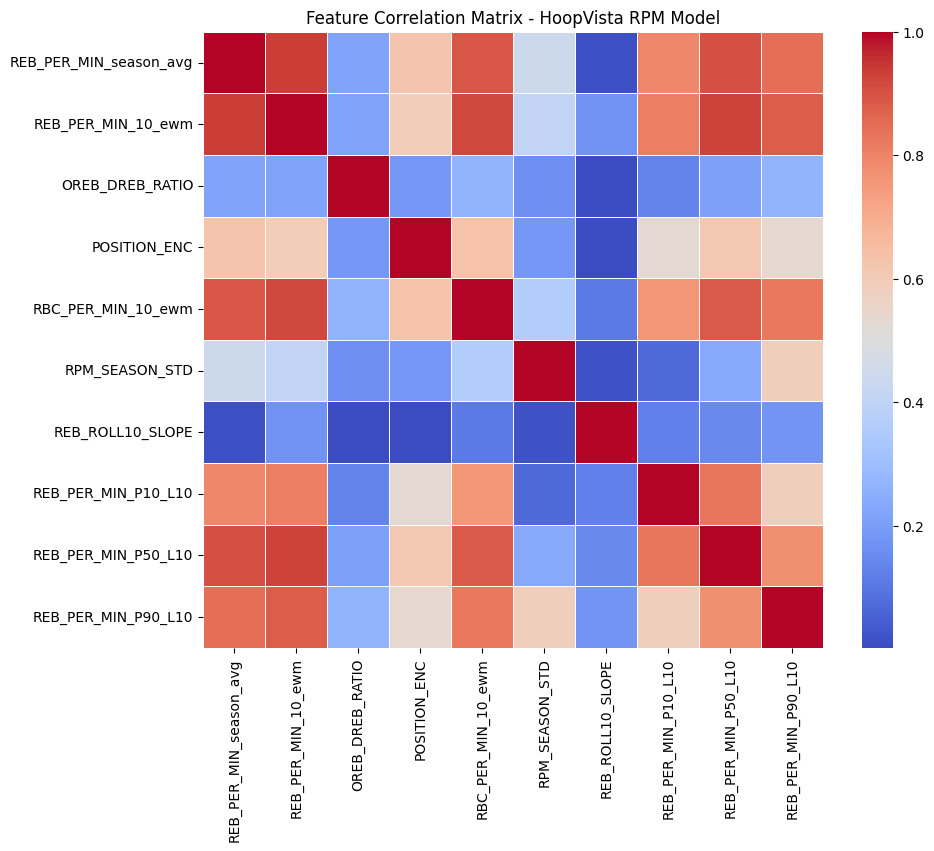

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [38]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the RPM model.
    """
    corr_matrix = df[features].corr().abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista RPM Model')
    plt.show()

    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))

    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")

    return to_drop

correlated_features = analyze_correlations(df, RPM_FEATURES)
correlated_features

In [16]:
# ════════════════════════════════════════════════════════════════════════════
# BLIND HOLDOUT TEST — S26
#
# NEW: evaluate on the season the model never saw during development.
# Run this cell once. If you iterate after seeing these numbers,
# S26 is no longer a clean holdout.
# ════════════════════════════════════════════════════════════════════════════

print("── S26 Blind Holdout Evaluation ─────────────────────────────────────")
print("  S21–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).")

X_train_full = rpm_df[RPM_FEATURES]
y_train_full = rpm_df["REB_PER_MIN"]
X_ho         = rpm_holdout[RPM_FEATURES]
y_ho         = rpm_holdout["REB_PER_MIN"]
starting_ho  = rpm_holdout["STARTING"].values

# Early stopping on last 10% of training only — S26 must not be eval_set
# or best_iteration is tuned to the holdout.
es_cutoff  = int(len(X_train_full) * 0.90)
X_es_train = X_train_full.iloc[:es_cutoff]
y_es_train = y_train_full.iloc[:es_cutoff]
X_es_val   = X_train_full.iloc[es_cutoff:]
y_es_val   = y_train_full.iloc[es_cutoff:]

models_ho, _ = fit_quantile_models(X_es_train, y_es_train, X_es_val, y_es_val)
preds_ho = {k: models_ho[k].predict(X_ho) for k in models_ho}

ho_metrics = score_fold(
    y_ho.values, preds_ho, models_ho,
    "S26 Blind Holdout",
    starting=starting_ho
)

# Compare walk-forward MAE vs holdout MAE
wf_mae_mean = np.mean([r["mae"] for r in wf_results])
ho_mae      = ho_metrics["mae"]
gap         = ho_mae - wf_mae_mean

print(f"\n{'─'*55}")
print(f"  Walk-forward MAE (mean, S21–S25)  : {wf_mae_mean:.4f}")
print(f"  Holdout MAE      (S26)            : {ho_mae:.4f}")
print(f"  Gap                               : {gap:+.4f}  {'⚠ investigate' if abs(gap) > 0.05 else '✓ acceptable'}")

# Per-quantile calibration on holdout
print(f"\nHoldout quantile calibration (should match target):")
for q_key, target in [("q_0.10", 0.10), ("q_0.50", 0.50), ("q_0.90", 0.90)]:
    pred            = preds_ho[q_key]
    actual          = y_ho.values
    actual_coverage = (actual <= pred).mean()
    delta           = actual_coverage - target
    flag            = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {q_key} | actual coverage: {actual_coverage:.1%}  target: {target:.0%}  delta: {delta:+.1%}  {flag}")

# Interval width on holdout
interval_width = preds_ho["q_0.90"] - preds_ho["q_0.10"]
print(f"\nHoldout 80% interval width (Q10→Q90):")
print(f"  mean: {interval_width.mean():.4f}  |  median: {np.median(interval_width):.4f}  |  std: {interval_width.std():.4f}")

── S26 Blind Holdout Evaluation ─────────────────────────────────────
  S21–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).

S26 Blind Holdout
  Overall  | n=24897 | MAE: 0.0725 | R²: 0.378 | 80% Coverage: 79.8%
  Starters   | n=13580 | MAE: 0.0660 | Coverage: 81.4%
  Bench      | n=11317 | MAE: 0.0803 | Coverage: 77.9%
  <0.15 reb/min        | n=11481 | MAE: 0.0596 | Coverage: 79.1%
  0.15-0.25 reb/min    | n= 7380 | MAE: 0.0547 | Coverage: 92.5%
  0.25-0.40 reb/min    | n= 4588 | MAE: 0.0952 | Coverage: 72.6%
  0.40+ reb/min        | n= 1448 | MAE: 0.1941 | Coverage: 43.1%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean, S21–S25)  : 0.0706
  Holdout MAE      (S26)            : 0.0725
  Gap                               : +0.0019  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 10.0%  target: 10%  delta: +0.0%  ✓
  q_0.50 | actual coverage: 50.3%  target: 50%  delt

In [17]:
import joblib
from pathlib import Path

# ── resolve save directory relative to this notebook ─────────────────────────
# Works on any machine regardless of OS or username.
# Structure: <repo_root>/src/models/saved_models/

REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd()
save_dir  = REPO_ROOT / "src" / "models" / "saved_models"
save_dir.mkdir(parents=True, exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_ho,
    "feature_names":   RPM_FEATURES,
    "fold_metrics":    wf_results,
    "holdout_metrics": ho_metrics,
    "train_end":       rpm_df["GAME_DATE"].max(),
    "val_end":         rpm_holdout["GAME_DATE"].max(),
}

save_path = save_dir / f"rpm_quantile_xgb_{rpm_holdout['GAME_DATE'].max().date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle        = joblib.load(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (S26 holdout): {mean_absolute_error(y_ho, test_preds):.4f}")
print(f"Trained on data up to        : {bundle['train_end'].date()}")
print(f"Holdout through              : {bundle['val_end'].date()}")

# ── inference ─────────────────────────────────────────────────────────────────
def predict_rpm(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a DataFrame with the same columns as RPM_FEATURES.
    Returns Q10 / Q50 / Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\src\models\saved_models\rpm_quantile_xgb_2026-05-12.joblib
Loaded model MAE (S26 holdout): 0.0725
Trained on data up to        : 2025-06-22
Holdout through              : 2026-05-12


In [18]:
from src.pipeline.props_pipeline.rpm_pipeline import rpm_pipeline

nums = rpm_pipeline(s26, "James Harden", "2026-05-14")
player_features = pd.DataFrame([nums], columns=RPM_FEATURES)
print(predict_rpm(player_features))
player_features

        q10       q50       q90
0  0.041705  0.097566  0.192904


,REB_PER_MIN_season_avg,REB_PER_MIN_10_ewm,RBC_PER_MIN_10_ewm,POSITION_ENC,REB_PER_MIN_roll5,DREB_PCT_season_avg,OPP_TEAM_DREB_ALLOWED,REB_ROLL10_SLOPE,EXPECTED_PACE,OPP_TEAM_OREB_ALLOWED,MIN_season_avg,RPM_SEASON_STD,OREB_PCT_season_avg,DREB_PER_MIN_season_avg,OPP_FGA_roll10
0,0.13,0.090121,0.179743,2.0,0.052247,0.12,29.226,-0.02,94.43,11.183,35.37,0.067021,0.02,0.117979,83.0
